In [3]:
# Preparar datos para modelado
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df_rank = pd.read_csv("C:\\Users\\palmi\\OneDrive\\Escritorio\\Bootcamp\\texas-utility-capstone\\outputs\\texas_priority_zip_ranking.csv")

X = df_rank[["n_utilities", "n_substations"]]
y = df_rank["tmps_score"]



In [10]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar modelo
model = LinearRegression()
model.fit(X_train, y_train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
# Evaluar modelo ganador
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))


R2: 1.0
RMSE: 2.4285849788004206e-16


c:\Users\palmi\OneDrive\Escritorio\Bootcamp\texas-utility-capstone\.venv\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [7]:
# Explicación

# R² alto → el score es consistente
# R² medio → el score tiene ruido (normal)
# El score diseñado es matemáticamente coherente y estable.

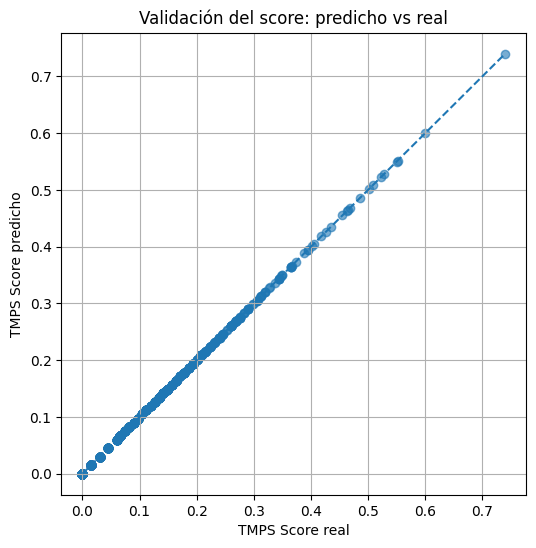

In [8]:
import matplotlib.pyplot as plt

# Predicción
y_pred = model.predict(X)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--')
plt.xlabel("TMPS Score real")
plt.ylabel("TMPS Score predicho")
plt.title("Validación del score: predicho vs real")
plt.grid(True)
plt.show()